In [105]:
%matplotlib inline


# Illustration of transforms

This example illustrates the various transforms available in `the
torchvision.transforms module <transforms>`.


In [103]:
from PIL import Image				# Image 处理图像
from pathlib import Path			# Path 处理文件路径
import matplotlib.pyplot as plt		# 绘图
import numpy as np					# 处理数组和矩阵

import torch						# pytorch 深度学习
import torchvision.transforms as T	# torchvision.transforms 用于对图像进行各种变换

# 设置一些绘图参数，savefig.bbox 用于控制图像保存时的边框大小
plt.rcParams["savefig.bbox"] = 'tight'

# 打开 assets/astronaut.jpg 路径下的图像文件，并将其赋值给 orig_img 变量
orig_img = Image.open(Path('assets') / 'astronaut.jpg')

# if you change the seed, make sure that the randomly-applied transforms
# properly show that the image can be both transformed and *not* transformed!
torch.manual_seed(0)

# 定义绘图函数
def plot(imgs, with_orig=True, row_title=None, **imshow_kwargs):
	# 判断 imgs 是否是一个二维列表，如果不是，则将其转换为二维列表
    if not isinstance(imgs[0], list):
        # Make a 2d grid even if there's just 1 row
        imgs = [imgs]
	
	# 根据 with_orig 参数确定网格的列数，并使用 plt.subplots 方法创建一个画布和一组子图
    num_rows = len(imgs)
    num_cols = len(imgs[0]) + with_orig
    fig, axs = plt.subplots(nrows=num_rows, ncols=num_cols, squeeze=False)
    
    # 遍历每一行和每一列的图像，并使用 ax.imshow 方法将其显示在对应的子图上，并使用 ax.set 方法去掉坐标轴和刻度
    for row_idx, row in enumerate(imgs):
        row = [orig_img] + row if with_orig else row
        for col_idx, img in enumerate(row):
            ax = axs[row_idx, col_idx]
            ax.imshow(np.asarray(img), **imshow_kwargs)
            ax.set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
	
	# 如果 with_orig 为真，则在第一列的子图上设置标题为 Original image
    if with_orig:
        axs[0, 0].set(title='Original image')
        axs[0, 0].title.set_size(8)
    
    # 如果 row_title 不为空，则在每行的第一列的子图上设置标签为 row_title 中对应的元素
    if row_title is not None:
        for row_idx in range(num_rows):
            axs[row_idx, 0].set(ylabel=row_title[row_idx])
	
	# 调整子图之间的间距
    plt.tight_layout()

## Compose
Take a look at transforms.Compose in advance

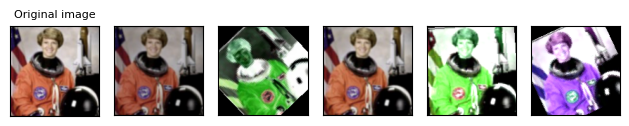

In [107]:
compose = T.Compose([
    # 将图像缩放到固定的形状（高度=宽度=128）
    T.Resize((128, 128)),
    # 对图像应用高斯模糊，核大小为3，标准差为0.1
    T.GaussianBlur(3, 0.1),
    # 随机地改变图像的亮度和色调。亮度因子从[0.5, 1.5]之间均匀地选择，色调因子从[-0.3, 0.3]之间均匀地选择。
    T.ColorJitter(brightness=0.5, hue=0.3),
    # 随机反转图像，概率为0.5
    T.RandomInvert(p=0.5),
    # 随机应用一个变换列表，概率为0.6。
    # 这里变换列表中只有一个变换，就是随机旋转图像，角度为0到60度之间
    T.RandomApply(transforms=[T.RandomRotation(degrees=(0, 60))], p=0.6),
])
demo = [compose(orig_img) for i in range(5)]
plot(demo)
plt.show()


## Pad
The :class:`~torchvision.transforms.Pad` transform
(see also :func:`~torchvision.transforms.functional.pad`)
fills image borders with some pixel values.



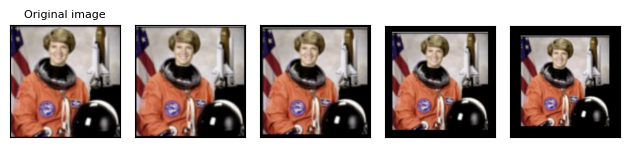

In [108]:
# padding 表示要填充在图像边界的像素数
padded_imgs = [T.Pad(padding=padding)(orig_img) for padding in (3, 10, 30, 50)]
plot(padded_imgs)
plt.show()

## Resize
The :class:`~torchvision.transforms.Resize` transform
(see also :func:`~torchvision.transforms.functional.resize`)
resizes an image.



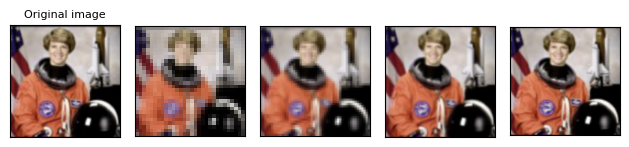

In [109]:
# size 表示要调整到的尺寸
resized_imgs = [T.Resize(size=size)(orig_img) for size in (30, 50, 100, orig_img.size)]
plot(resized_imgs)
plt.show()

In [70]:
print(orig_img.size)

(418, 424)


## CenterCrop
The :class:`~torchvision.transforms.CenterCrop` transform
(see also :func:`~torchvision.transforms.functional.center_crop`)
crops the given image at the center.



In [71]:
# size 表示中心裁剪的尺寸
center_crops = [T.CenterCrop(size=size)(orig_img) for size in (30, 50, 100, orig_img.size)]
plot(center_crops)

## FiveCrop
The :class:`~torchvision.transforms.FiveCrop` transform
(see also :func:`~torchvision.transforms.functional.five_crop`)
crops the given image into four corners and the central crop.



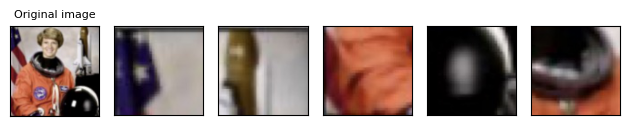

In [110]:
(top_left, top_right, bottom_left, bottom_right, center) = T.FiveCrop(size=(100, 100))(orig_img)
plot([top_left, top_right, bottom_left, bottom_right, center])
plt.show()

## Grayscale
The :class:`~torchvision.transforms.Grayscale` transform
(see also :func:`~torchvision.transforms.functional.to_grayscale`)
converts an image to grayscale



In [73]:
gray_img = T.Grayscale()(orig_img)
plot([gray_img], cmap='gray')

## Random transforms
The following transforms are random, which means that the same transfomer
instance will produce different result each time it transforms a given image.

### ColorJitter
The :class:`~torchvision.transforms.ColorJitter` transform
randomly changes the brightness, saturation, and other properties of an image.



In [74]:
jitter = T.ColorJitter(brightness=.5, hue=.3)
jitted_imgs = [jitter(orig_img) for _ in range(4)]
plot(jitted_imgs)

### GaussianBlur
The :class:`~torchvision.transforms.GaussianBlur` transform
(see also :func:`~torchvision.transforms.functional.gaussian_blur`)
performs gaussian blur transform on an image.



In [75]:
blurrer = T.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5))
blurred_imgs = [blurrer(orig_img) for _ in range(4)]
plot(blurred_imgs)

### RandomPerspective
The :class:`~torchvision.transforms.RandomPerspective` transform
(see also :func:`~torchvision.transforms.functional.perspective`)
performs random perspective transform on an image.



In [76]:
perspective_transformer = T.RandomPerspective(distortion_scale=0.6, p=1.0)
perspective_imgs = [perspective_transformer(orig_img) for _ in range(4)]
plot(perspective_imgs)

### RandomRotation
The :class:`~torchvision.transforms.RandomRotation` transform
(see also :func:`~torchvision.transforms.functional.rotate`)
rotates an image with random angle.



In [77]:
# 随机旋转
rotater = T.RandomRotation(degrees=(0, 180))
rotated_imgs = [rotater(orig_img) for _ in range(4)]
plot(rotated_imgs)

### RandomAffine
The :class:`~torchvision.transforms.RandomAffine` transform
(see also :func:`~torchvision.transforms.functional.affine`)
performs random affine transform on an image.



In [78]:
# 随机仿射变换
affine_transfomer = T.RandomAffine(degrees=(30, 70), translate=(0.1, 0.3), scale=(0.5, 0.75))
affine_imgs = [affine_transfomer(orig_img) for _ in range(4)]
plot(affine_imgs)

### ElasticTransform
The :class:`~torchvision.transforms.ElasticTransform` transform
(see also :func:`~torchvision.transforms.functional.elastic_transform`)
Randomly transforms the morphology of objects in images and produces a
see-through-water-like effect.



In [79]:
# 在图像上添加一些小的扭曲
elastic_transformer = T.ElasticTransform(alpha=250.0)
transformed_imgs = [elastic_transformer(orig_img) for _ in range(2)]
plot(transformed_imgs)

### RandomCrop
The :class:`~torchvision.transforms.RandomCrop` transform
(see also :func:`~torchvision.transforms.functional.crop`)
crops an image at a random location.



In [80]:
# 随机裁剪
cropper = T.RandomCrop(size=(128, 128))
crops = [cropper(orig_img) for _ in range(4)]
plot(crops)

### RandomResizedCrop
The :class:`~torchvision.transforms.RandomResizedCrop` transform
(see also :func:`~torchvision.transforms.functional.resized_crop`)
crops an image at a random location, and then resizes the crop to a given
size.



In [81]:
# 随机缩放并裁剪
resize_cropper = T.RandomResizedCrop(size=(32, 32))
resized_crops = [resize_cropper(orig_img) for _ in range(4)]
plot(resized_crops)

### RandomInvert
The :class:`~torchvision.transforms.RandomInvert` transform
(see also :func:`~torchvision.transforms.functional.invert`)
randomly inverts the colors of the given image.



In [82]:
# 以给定的概率随机地变换给定图像的颜色，默认为 0.5
inverter = T.RandomInvert()
invertered_imgs = [inverter(orig_img) for _ in range(4)]
plot(invertered_imgs)

### RandomPosterize
The :class:`~torchvision.transforms.RandomPosterize` transform
(see also :func:`~torchvision.transforms.functional.posterize`)
randomly posterizes the image by reducing the number of bits
of each color channel.



In [83]:
# 对图像进行随机的色彩分层，各channel像素值的bits位数降为2
posterizer = T.RandomPosterize(bits=2)
posterized_imgs = [posterizer(orig_img) for _ in range(4)]
plot(posterized_imgs)

### RandomSolarize
The :class:`~torchvision.transforms.RandomSolarize` transform
(see also :func:`~torchvision.transforms.functional.solarize`)
randomly solarizes the image by inverting all pixel values above
the threshold.



In [84]:
# 图像有 0.5 的概率反转大于 192 的像素
solarizer = T.RandomSolarize(threshold=192.0)
solarized_imgs = [solarizer(orig_img) for _ in range(4)]
plot(solarized_imgs)

### RandomAdjustSharpness
The :class:`~torchvision.transforms.RandomAdjustSharpness` transform
(see also :func:`~torchvision.transforms.functional.adjust_sharpness`)
randomly adjusts the sharpness of the given image.



In [85]:
# 图像有 0.5 的概率提升 2 倍锐度
sharpness_adjuster = T.RandomAdjustSharpness(sharpness_factor=2)
sharpened_imgs = [sharpness_adjuster(orig_img) for _ in range(4)]
plot(sharpened_imgs)

### RandomAutocontrast
The :class:`~torchvision.transforms.RandomAutocontrast` transform
(see also :func:`~torchvision.transforms.functional.autocontrast`)
randomly applies autocontrast to the given image.



In [86]:
autocontraster = T.RandomAutocontrast()
autocontrasted_imgs = [autocontraster(orig_img) for _ in range(4)]
plot(autocontrasted_imgs)

### RandomEqualize
The :class:`~torchvision.transforms.RandomEqualize` transform
(see also :func:`~torchvision.transforms.functional.equalize`)
randomly equalizes the histogram of the given image.



In [87]:
equalizer = T.RandomEqualize()
equalized_imgs = [equalizer(orig_img) for _ in range(4)]
plot(equalized_imgs)

### AutoAugment
The :class:`~torchvision.transforms.AutoAugment` transform
automatically augments data based on a given auto-augmentation policy.
See :class:`~torchvision.transforms.AutoAugmentPolicy` for the available policies.



In [88]:
# 自动图像增强
policies = [T.AutoAugmentPolicy.CIFAR10, T.AutoAugmentPolicy.IMAGENET, T.AutoAugmentPolicy.SVHN]
augmenters = [T.AutoAugment(policy) for policy in policies]
imgs = [
    [augmenter(orig_img) for _ in range(4)]
    for augmenter in augmenters
]
row_title = [str(policy).split('.')[-1] for policy in policies]
plot(imgs, row_title=row_title)

### RandAugment
The :class:`~torchvision.transforms.RandAugment` transform automatically augments the data.



In [89]:
augmenter = T.RandAugment()
imgs = [augmenter(orig_img) for _ in range(4)]
plot(imgs)

### TrivialAugmentWide
The :class:`~torchvision.transforms.TrivialAugmentWide` transform automatically augments the data.



In [90]:
augmenter = T.TrivialAugmentWide()
imgs = [augmenter(orig_img) for _ in range(4)]
plot(imgs)

### AugMix
The :class:`~torchvision.transforms.AugMix` transform automatically augments the data.



In [91]:
augmenter = T.AugMix()
imgs = [augmenter(orig_img) for _ in range(4)]
plot(imgs)

## Randomly-applied transforms

Some transforms are randomly-applied given a probability ``p``.  That is, the
transformed image may actually be the same as the original one, even when
called with the same transformer instance!

### RandomHorizontalFlip
The :class:`~torchvision.transforms.RandomHorizontalFlip` transform
(see also :func:`~torchvision.transforms.functional.hflip`)
performs horizontal flip of an image, with a given probability.



In [92]:
hflipper = T.RandomHorizontalFlip(p=0.5)
transformed_imgs = [hflipper(orig_img) for _ in range(4)]
plot(transformed_imgs)

### RandomVerticalFlip
The :class:`~torchvision.transforms.RandomVerticalFlip` transform
(see also :func:`~torchvision.transforms.functional.vflip`)
performs vertical flip of an image, with a given probability.



In [93]:
vflipper = T.RandomVerticalFlip(p=0.5)
transformed_imgs = [vflipper(orig_img) for _ in range(4)]
plot(transformed_imgs)

### RandomApply
The :class:`~torchvision.transforms.RandomApply` transform
randomly applies a list of transforms, with a given probability.



In [94]:
# 图像有 0.5 的概率应用列表中的所有变换
applier = T.RandomApply(transforms=[T.RandomCrop(size=(64, 64))], p=0.5)
transformed_imgs = [applier(orig_img) for _ in range(4)]
plot(transformed_imgs)

# RandomChoice
The :class:`~torchvision.transforms.RandomChoice` transform
randomly apply single transformation picked from a list, with a given probability.

In [101]:
# 随机应用列表中的变换之一，p=None意味着各变换被选中的概率相同
applier = T.RandomChoice(transforms=[T.RandomCrop(size=(64, 64)), T.ColorJitter(brightness=.5, hue=.3), T.Lambda(lambda x: x)], p=None)
transformed_imgs = [applier(orig_img) for _ in range(4)]
plot(transformed_imgs)